## Install Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
import warnings
from sklearn.datasets import make_classification

## Import the Dataset

In [ ]:

df = pd.read_csv('/content/drive/MyDrive/DATASET/6. diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Dataset Visualization**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.shape

(768, 9)

In [ ]:

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


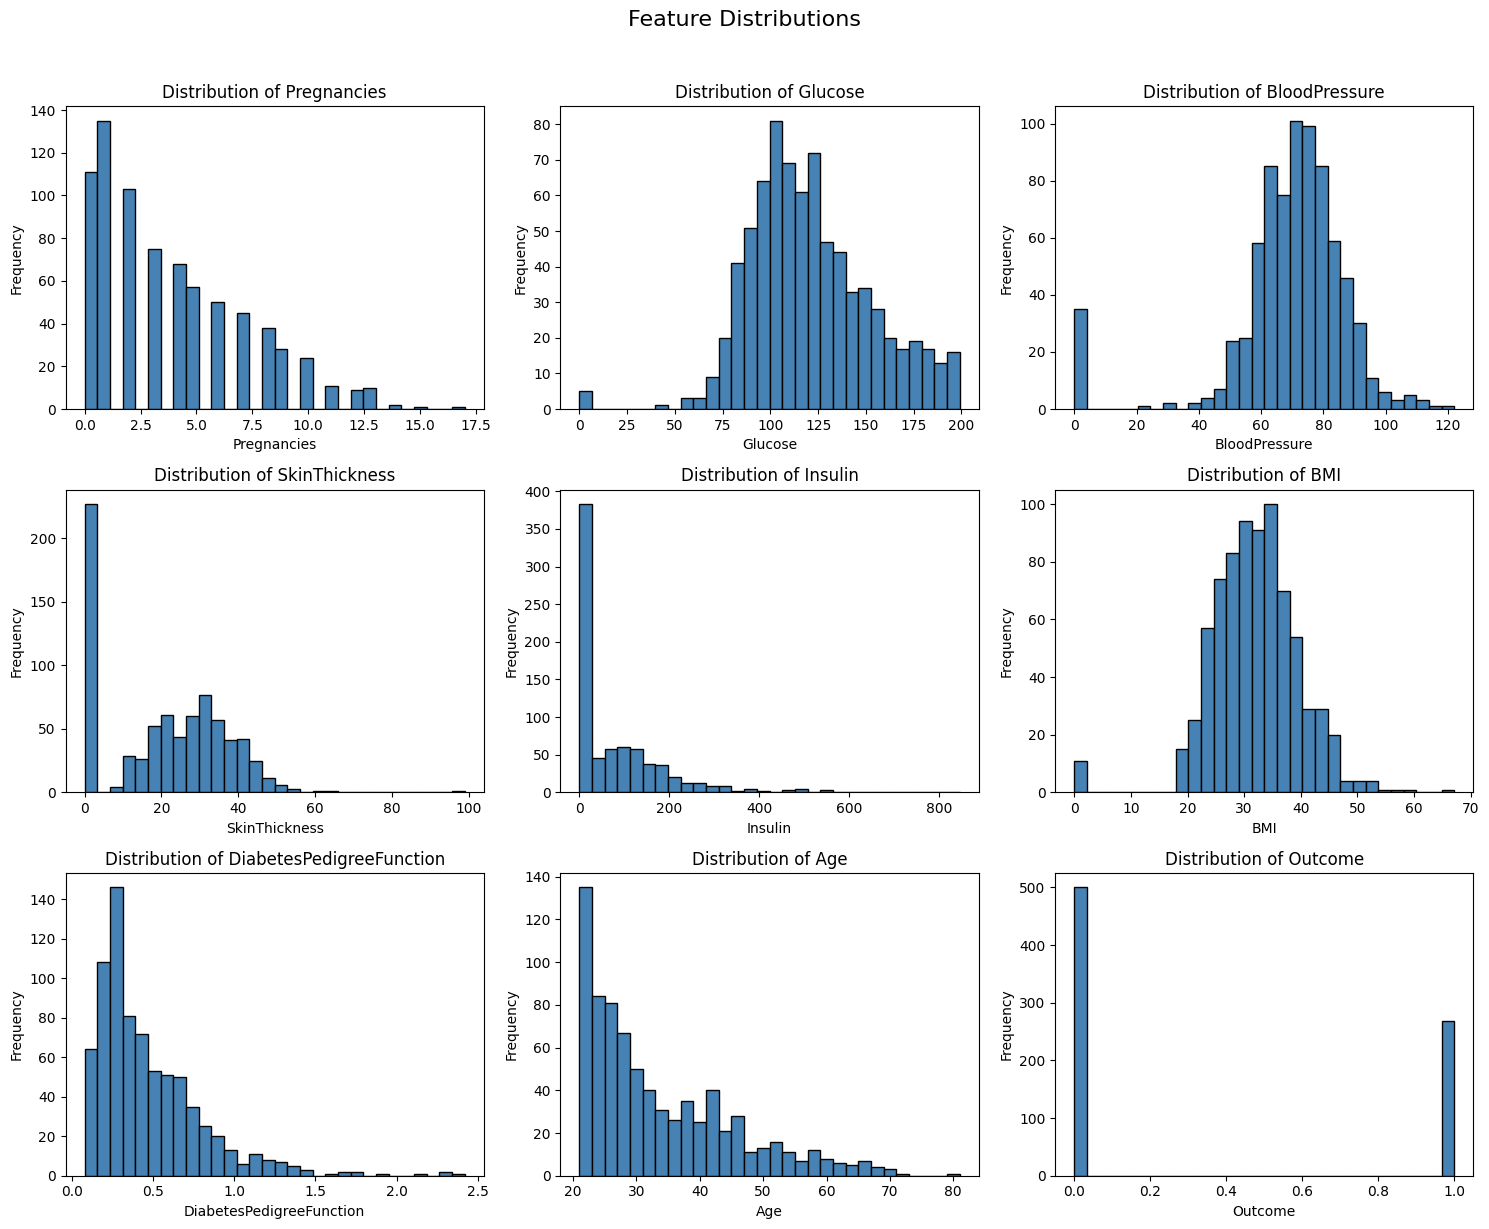

In [ ]:
# Distribution of all features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.suptitle('Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

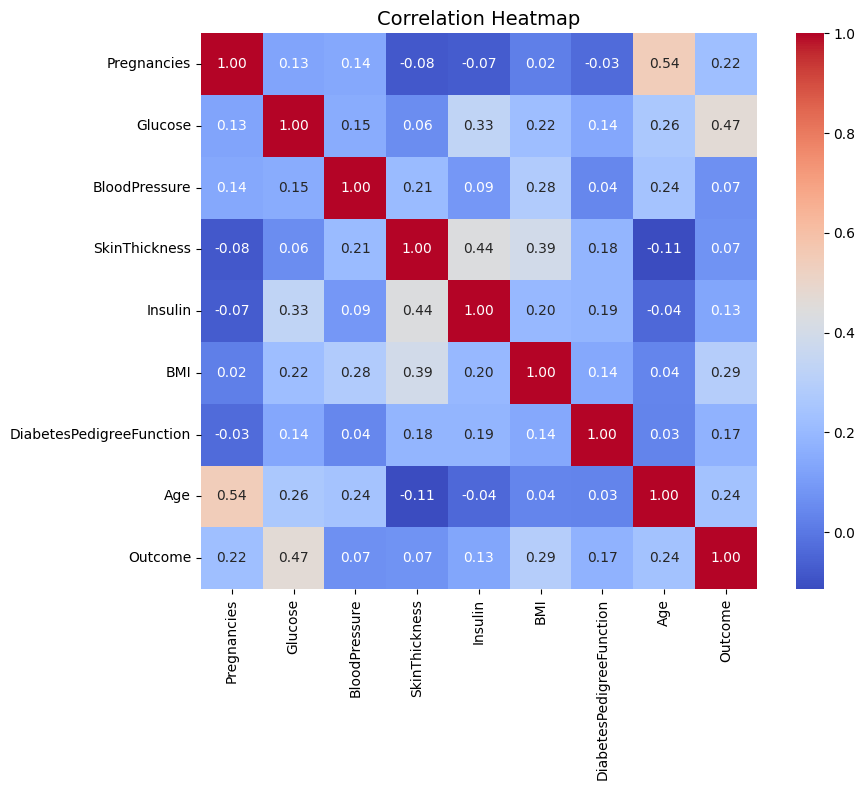

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

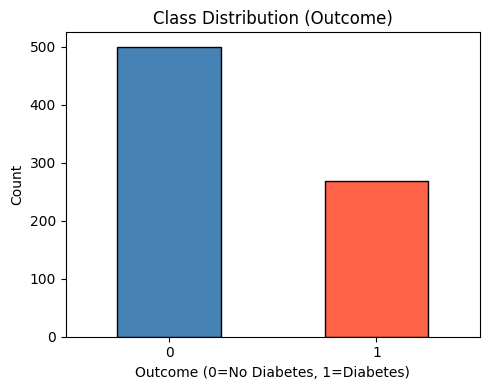

Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
# Class distribution
plt.figure(figsize=(5, 4))
df['Outcome'].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.title('Class Distribution (Outcome)')
plt.xlabel('Outcome (0=No Diabetes, 1=Diabetes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(df['Outcome'].value_counts())

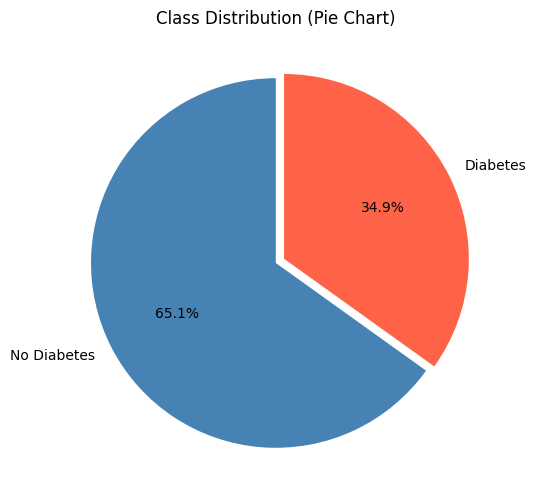

In [ ]:
plt.figure(figsize=(6,6))
counts = df['Outcome'].value_counts()
plt.pie(counts,
        labels=['No Diabetes', 'Diabetes'],
        autopct='%1.1f%%',
        colors=['steelblue', 'tomato'],
        startangle=90,
        explode=(0, 0.05))

plt.title('Class Distribution (Pie Chart)')
plt.show()

## Data Preprocessing

### i. Handling Missing Values

In [ ]:
print('Missing values per column:')
print(df.isnull().sum())
# In this dataset, 0 values in medical columns are actually missing
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('\nZero counts (treated as missing) in medical columns:')
for col in zero_cols:
    print(f'  {col}: {(df[col] == 0).sum()} zeros')

# Replace 0s with NaN and fill with median
df_clean = df.copy()
for col in zero_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

print('Missing values handled by median imputation')
print('Remaining nulls:', df_clean.isnull().sum().sum())

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Zero counts (treated as missing) in medical columns:
  Glucose: 5 zeros
  BloodPressure: 35 zeros
  SkinThickness: 227 zeros
  Insulin: 374 zeros
  BMI: 11 zeros
Missing values handled by median imputation
Remaining nulls: 0


### ii.Standardization

In [ ]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('Before Standardization (mean, std):')
print(X.describe().loc[['mean','std']].round(2))
print('\nAfter Standardization (mean ≈ 0, std ≈ 1):')
print(X_scaled.describe().loc[['mean','std']].round(2))

Before Standardization (mean, std):
      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
mean         3.85   121.66          72.39          29.11   140.67  32.46   
std          3.37    30.44          12.10           8.79    86.38   6.88   

      DiabetesPedigreeFunction    Age  
mean                      0.47  33.24  
std                       0.33  11.76  

After Standardization (mean ≈ 0, std ≈ 1):
      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI  \
mean         -0.0      0.0            0.0           -0.0      0.0  0.0   
std           1.0      1.0            1.0            1.0      1.0  1.0   

      DiabetesPedigreeFunction  Age  
mean                       0.0  0.0  
std                        1.0  1.0  


### iii. Encoding Categorical Data

In [ ]:
# Check for categorical columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns found:', cat_cols if cat_cols else 'None')

# --- Demonstration of Label Encoding ---
print('\n--- Label Encoding Demo ---')
demo_df = pd.DataFrame({'Gender': ['Male', 'Female', 'Female', 'Male']})
le = LabelEncoder()
demo_df['Gender_LabelEncoded'] = le.fit_transform(demo_df['Gender'])
print(demo_df)

# --- Demonstration of One-Hot Encoding ---
print('\n--- One-Hot Encoding Demo ---')
demo_ohe = pd.get_dummies(demo_df[['Gender']], prefix='Gender')
print(demo_ohe)

print('\n No categorical columns in this dataset — encoding not needed for modeling.')

Categorical columns found: None

--- Label Encoding Demo ---
   Gender  Gender_LabelEncoded
0    Male                    1
1  Female                    0
2  Female                    0
3    Male                    1

--- One-Hot Encoding Demo ---
   Gender_Female  Gender_Male
0          False         True
1           True        False
2           True        False
3          False         True

 No categorical columns in this dataset — encoding not needed for modeling.


### iv. Handling Imbalanced Data

Original class counts:
Outcome
0    500
1    268
Name: count, dtype: int64


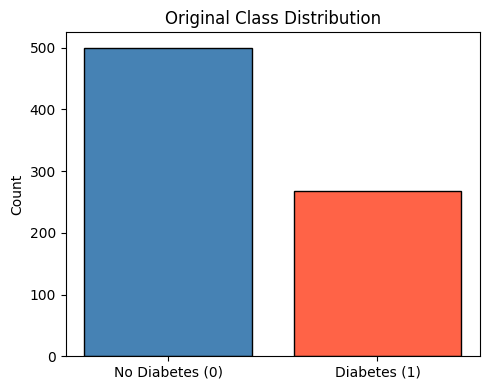

In [ ]:
print('Original class counts:')
print(y.value_counts())

plt.figure(figsize=(5, 4))
plt.bar(['No Diabetes (0)', 'Diabetes (1)'],
        y.value_counts().sort_index(),
        color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Original Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

After SMOTE:
  Class 0 (No Diabetes): 500
  Class 1 (Diabetes)   : 500


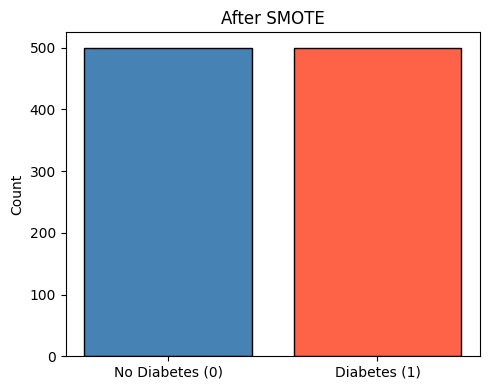

In [ ]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_scaled, y)
counts_smote = pd.Series(y_smote).value_counts().sort_index()

print('After SMOTE:')
print(f'  Class 0 (No Diabetes): {counts_smote[0]}')
print(f'  Class 1 (Diabetes)   : {counts_smote[1]}')

plt.figure(figsize=(5, 4))
plt.bar(['No Diabetes (0)', 'Diabetes (1)'],
        counts_smote, color=['steelblue', 'tomato'], edgecolor='black')
plt.title('After SMOTE')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

After Random Over Sampling:
  Class 0 (No Diabetes): 500
  Class 1 (Diabetes)   : 500


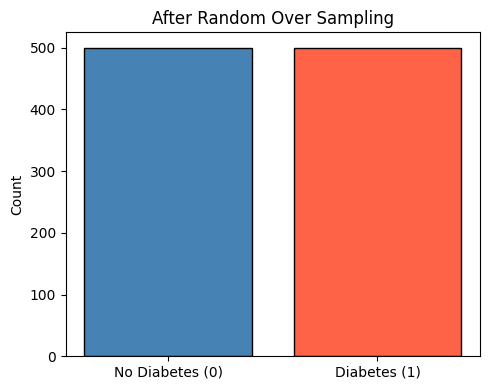

In [ ]:
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_scaled, y)
counts_ros = pd.Series(y_ros).value_counts().sort_index()

print('After Random Over Sampling:')
print(f'  Class 0 (No Diabetes): {counts_ros[0]}')
print(f'  Class 1 (Diabetes)   : {counts_ros[1]}')

plt.figure(figsize=(5, 4))
plt.bar(['No Diabetes (0)', 'Diabetes (1)'],
        counts_ros, color=['steelblue', 'tomato'], edgecolor='black')
plt.title('After Random Over Sampling')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

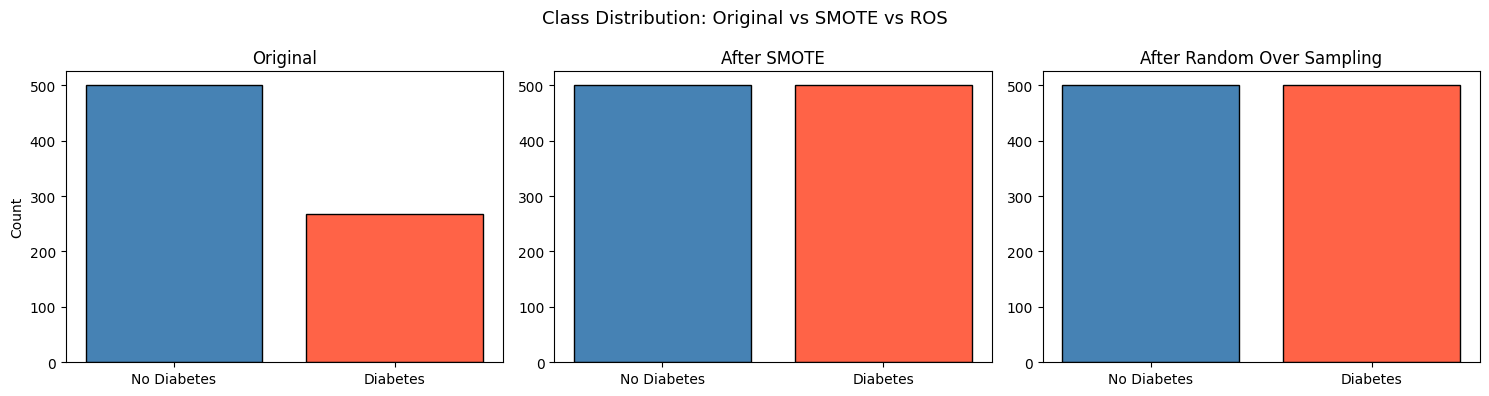

Original → Class 0: 500, Class 1: 268
SMOTE    → Class 0: 500, Class 1: 500
ROS      → Class 0: 500, Class 1: 500


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(['No Diabetes', 'Diabetes'],
            y.value_counts().sort_index(),
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Original')
axes[0].set_ylabel('Count')

axes[1].bar(['No Diabetes', 'Diabetes'],
            counts_smote, color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('After SMOTE')

axes[2].bar(['No Diabetes', 'Diabetes'],
            counts_ros, color=['steelblue', 'tomato'], edgecolor='black')
axes[2].set_title('After Random Over Sampling')

plt.suptitle('Class Distribution: Original vs SMOTE vs ROS', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Original → Class 0: {y.value_counts()[0]}, Class 1: {y.value_counts()[1]}')
print(f'SMOTE    → Class 0: {counts_smote[0]}, Class 1: {counts_smote[1]}')
print(f'ROS      → Class 0: {counts_ros[0]}, Class 1: {counts_ros[1]}')

### v. Finding Feature Importance

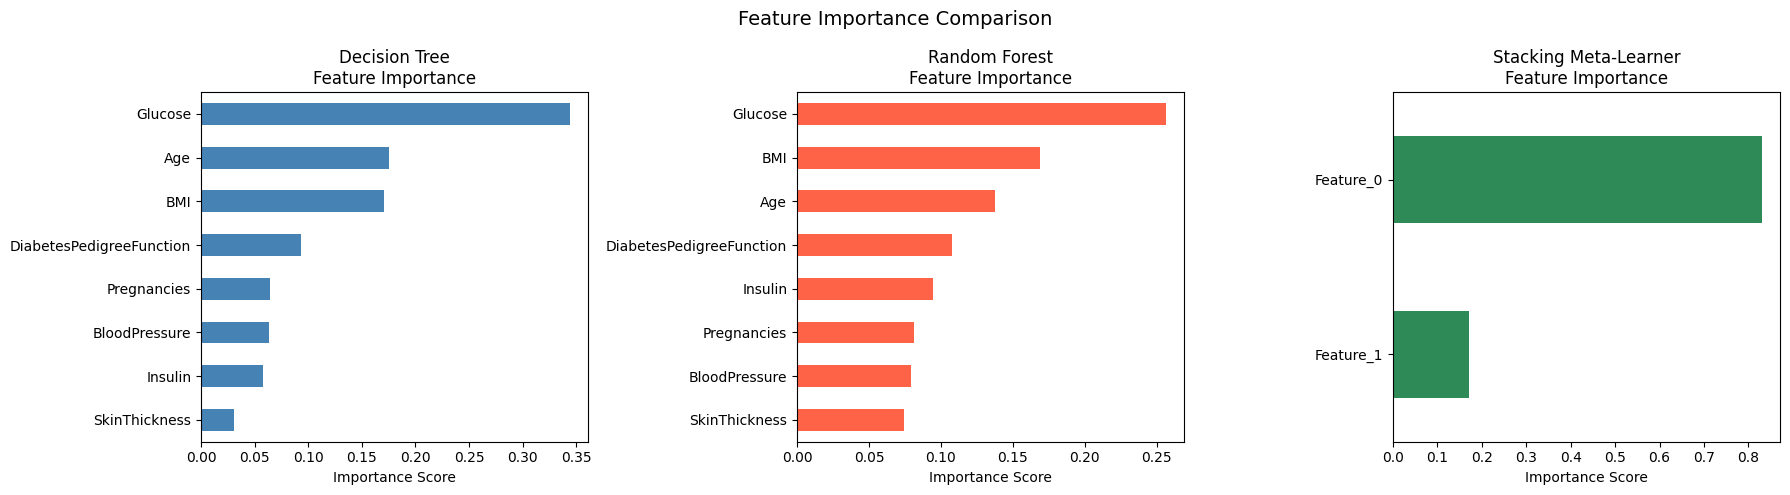

In [ ]:
feature_names = X.columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Decision Tree Feature Importance
dt_fi = DecisionTreeClassifier(random_state=42)
dt_fi.fit(X_final, y_final)
importances_dt = pd.Series(dt_fi.feature_importances_, index=feature_names).sort_values(ascending=True)
importances_dt.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Decision Tree\nFeature Importance')
axes[0].set_xlabel('Importance Score')

# 2. Random Forest Feature Importance
rf_fi = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fi.fit(X_final, y_final)
importances_rf = pd.Series(rf_fi.feature_importances_, index=feature_names).sort_values(ascending=True)
importances_rf.plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Random Forest\nFeature Importance')
axes[1].set_xlabel('Importance Score')

# 3. Stacking - use RF coefficients as proxy for feature importance
estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('dt', DecisionTreeClassifier(random_state=42))
]
stacking_clf = StackingClassifier(estimators=estimators,
                                   final_estimator=RandomForestClassifier(n_estimators=50, random_state=42))
stacking_clf.fit(X_final, y_final)
# Extract RF final estimator importances
stack_importances = pd.Series(
    stacking_clf.final_estimator_.feature_importances_,
    index=[f'Feature_{i}' for i in range(len(stacking_clf.final_estimator_.feature_importances_))]
).sort_values(ascending=True)
stack_importances.plot(kind='barh', ax=axes[2], color='seagreen')
axes[2].set_title('Stacking Meta-Learner\nFeature Importance')
axes[2].set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison', fontsize=14)
plt.tight_layout()
plt.show()

## Split Dataset (20% Test, 80% Train)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.20, random_state=42, stratify=y_final
)

print(f'Training set size : {X_train.shape[0]} samples')
print(f'Testing set size  : {X_test.shape[0]} samples')
print(f'Train class dist  : {pd.Series(y_train).value_counts().to_dict()}')
print(f'Test class dist   : {pd.Series(y_test).value_counts().to_dict()}')

Training set size : 800 samples
Testing set size  : 200 samples
Train class dist  : {1: 400, 0: 400}
Test class dist   : {1: 100, 0: 100}


## Train ML Models (3 Selected: Logistic Regression, Random Forest, SVM)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
print('Logistic Regression — Training complete')

Logistic Regression — Training complete


In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print('Random Forest — Training complete')

Random Forest — Training complete


In [ ]:
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)
print('SVM — Training complete')

SVM — Training complete


## Test & Evaluate Models

### i. Confusion Matrix

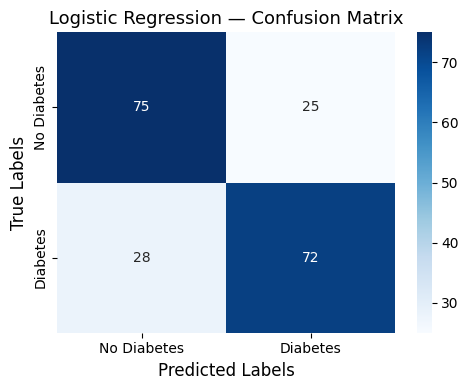

In [ ]:
y_pred_lr = lr_model.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='g', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.title('Logistic Regression — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

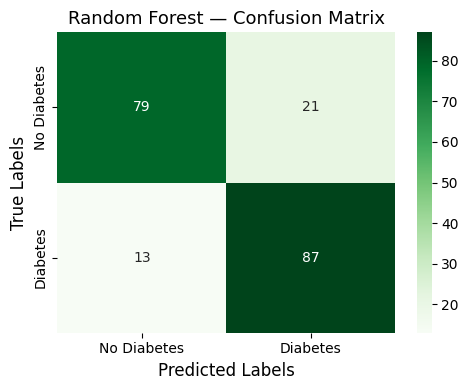

In [ ]:
y_pred_rf = rf_model.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='g', cmap='Greens',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.title('Random Forest — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

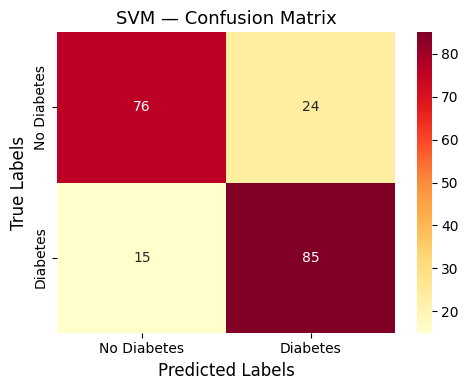

In [ ]:
y_pred_svm = svm_model.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt='g', cmap='YlOrRd',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.title('SVM — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

### ii. Classification Report

In [ ]:
print('Classification Report — Logistic Regression')
print('='*50)
print(classification_report(y_test, y_pred_lr, target_names=['No Diabetes', 'Diabetes']))

print(f'Accuracy : {accuracy_score(y_test, y_pred_lr)*100:.4f}%')
print(f'Precision: {precision_score(y_test, y_pred_lr, average="macro")*100:.4f}%')
print(f'Recall   : {recall_score(y_test, y_pred_lr, average="macro")*100:.4f}%')
print(f'F1-Score : {f1_score(y_test, y_pred_lr, average="macro")*100:.4f}%')

Classification Report — Logistic Regression
              precision    recall  f1-score   support

 No Diabetes       0.73      0.75      0.74       100
    Diabetes       0.74      0.72      0.73       100

    accuracy                           0.73       200
   macro avg       0.74      0.73      0.73       200
weighted avg       0.74      0.73      0.73       200

Accuracy : 73.5000%
Precision: 73.5212%
Recall   : 73.5000%
F1-Score : 73.4940%


In [ ]:
print('Classification Report — Random Forest')
print('='*50)
print(classification_report(y_test, y_pred_rf, target_names=['No Diabetes', 'Diabetes']))

print(f'Accuracy : {accuracy_score(y_test, y_pred_rf)*100:.4f}%')
print(f'Precision: {precision_score(y_test, y_pred_rf, average="macro")*100:.4f}%')
print(f'Recall   : {recall_score(y_test, y_pred_rf, average="macro")*100:.4f}%')
print(f'F1-Score : {f1_score(y_test, y_pred_rf, average="macro")*100:.4f}%')

Classification Report — Random Forest
              precision    recall  f1-score   support

 No Diabetes       0.86      0.79      0.82       100
    Diabetes       0.81      0.87      0.84       100

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200

Accuracy : 83.0000%
Precision: 83.2126%
Recall   : 83.0000%
F1-Score : 82.9728%


In [ ]:
print('Classification Report — SVM')
print('='*50)
print(classification_report(y_test, y_pred_svm, target_names=['No Diabetes', 'Diabetes']))

print(f'Accuracy : {accuracy_score(y_test, y_pred_svm)*100:.4f}%')
print(f'Precision: {precision_score(y_test, y_pred_svm, average="macro")*100:.4f}%')
print(f'Recall   : {recall_score(y_test, y_pred_svm, average="macro")*100:.4f}%')
print(f'F1-Score : {f1_score(y_test, y_pred_svm, average="macro")*100:.4f}%')

Classification Report — SVM
              precision    recall  f1-score   support

 No Diabetes       0.84      0.76      0.80       100
    Diabetes       0.78      0.85      0.81       100

    accuracy                           0.81       200
   macro avg       0.81      0.80      0.80       200
weighted avg       0.81      0.81      0.80       200

Accuracy : 80.5000%
Precision: 80.7491%
Recall   : 80.5000%
F1-Score : 80.4604%


### iii. ROC Curve

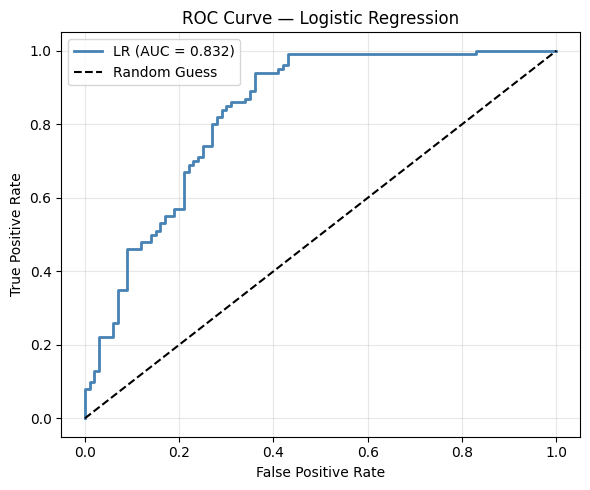

In [ ]:
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, color='steelblue', lw=2, label=f'LR (AUC = {auc_lr:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random Guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

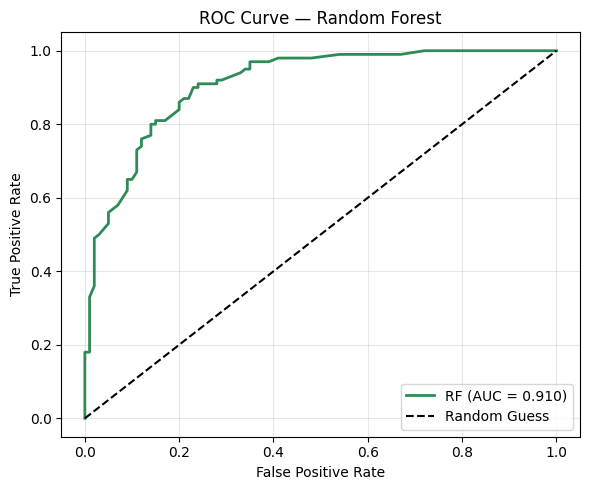

In [ ]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, color='seagreen', lw=2, label=f'RF (AUC = {auc_rf:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random Guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

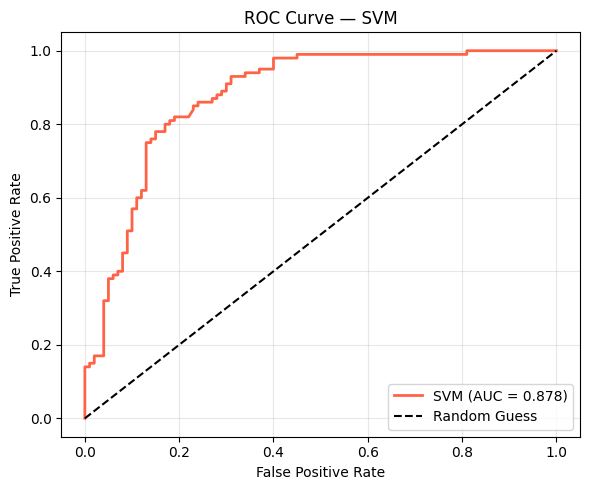

In [ ]:
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(6, 5))
plt.plot(fpr_svm, tpr_svm, color='tomato', lw=2, label=f'SVM (AUC = {auc_svm:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random Guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — SVM')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

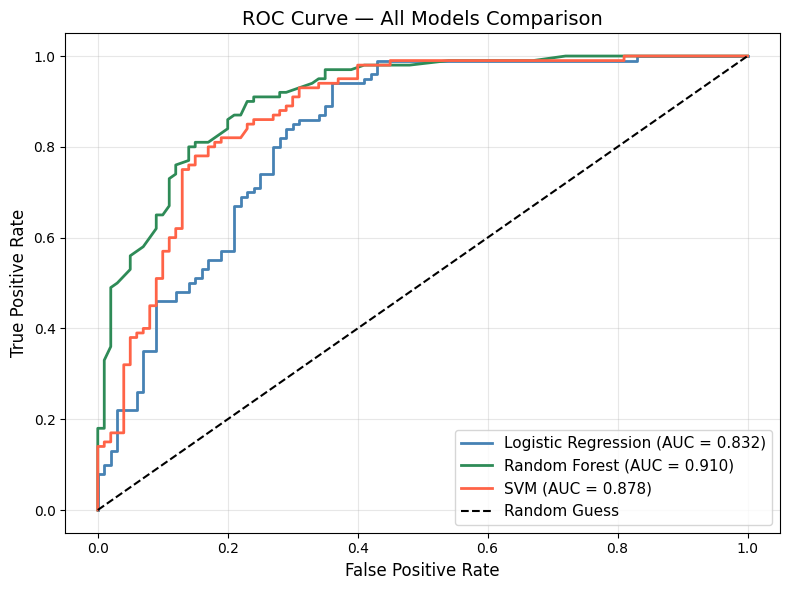

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr,  tpr_lr,  color='steelblue', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf,  tpr_rf,  color='seagreen',  lw=2, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_svm, tpr_svm, color='tomato',    lw=2, label=f'SVM (AUC = {auc_svm:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1.5, label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — All Models Comparison', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()